# Role Coordination Game V2

This notebook implements a cooperative multi-agent role coordination game where three players must coordinate to defeat an enemy by adopting complementary roles (Fighter, Tank, Healer).

## Overview

**Key Features:**
- **Bayesian Role Inference**: Players use probabilistic inference to deduce each other's roles from observed actions
- **Dynamic Enemy Health**: Enemy health changes based on team composition and actions
- **Utility-Based Role Assignment**: Player stats influence role suitability
- **Multiple Variants**: Compare unique vs non-unique role constraints, basic vs enhanced combat systems

**Game Mechanics:**
- 3 Players must coordinate roles: Fighter (damage), Tank (defense), Healer (support)
- Enemy health progresses through 5 states: DEAD → LOW → MEDIUM → HIGH → FULL
- Team health progresses through 5 states: DEAD → LOW → MEDIUM → HIGH → FULL
- Team wins by reducing enemy health to DEAD
- Attacking increases probability that enemy transitions to a lower health
- Defending decreases probability that team health transitions to a lower health
- Healing increases probability that team health transitions to a higher health
- Players infer roles through Bayesian updating based on observed actions


## 1. Imports and Setup

In [146]:
from memo import memo
import jax
import jax.numpy as np
from enum import IntEnum, auto
import random

## 2. Game Definition

This section defines the core game mechanics:
- **Roles**: Fighter, Tank, Healer (each has different action preferences)
- **Actions**: Attack, Defend, Heal
- **Enemy Health States**: DEAD, LOW, MEDIUM, HIGH, FULL
- **TEAM Health States**: DEAD, LOW, MEDIUM, HIGH, FULL
- **Role Policies**: Probability distributions over actions given role and enemy/team health
- **Transition Function**: How enemy/team health changes based on number of attackers / defenders / healers
- **Player Stats**: Each player has STR/DEF/SUP stats that influence role suitability


In [147]:
class Role(IntEnum): Fighter = 0; Tank = 1; Healer = 2
class Action(IntEnum): Attack = 0; Defend = 1; Heal = 2
class EnemyHealth(IntEnum): DEAD = 0; LOW = 1; MEDIUM = 2; HIGH = 3; FULL = 4
class TeamHealth(IntEnum): DEAD = 0; LOW = 1; MEDIUM = 2; HIGH = 3; FULL = 4

# ROLE_ACTION_STATE_PROBS[role, enemy_health, team_health, action]
# Probabilities: P(action | role, enemy_health, team_health)
# Roles adapt their behavior based on both enemy and team health
ROLE_ACTION_STATE_PROBS = np.array([
    # Fighter probabilities [enemy_health, team_health, action]
    [
        # DEAD enemy
        [[0.10, 0.45, 0.45], [0.10, 0.45, 0.45], [0.10, 0.45, 0.45], [0.10, 0.45, 0.45], [0.10, 0.45, 0.45]],
        # LOW enemy
        [[0.50, 0.30, 0.20], [0.55, 0.30, 0.15], [0.60, 0.25, 0.15], [0.65, 0.20, 0.15], [0.70, 0.20, 0.10]],
        # MEDIUM enemy
        [[0.45, 0.35, 0.20], [0.50, 0.35, 0.15], [0.55, 0.30, 0.15], [0.60, 0.25, 0.15], [0.65, 0.25, 0.10]],
        # HIGH enemy
        [[0.40, 0.40, 0.20], [0.45, 0.40, 0.15], [0.50, 0.35, 0.15], [0.55, 0.30, 0.15], [0.60, 0.30, 0.10]],
        # FULL enemy
        [[0.35, 0.45, 0.20], [0.40, 0.45, 0.15], [0.45, 0.40, 0.15], [0.50, 0.35, 0.15], [0.55, 0.35, 0.10]],
    ],
    # Tank probabilities [enemy_health, team_health, action]
    [
        # DEAD enemy
        [[0.10, 0.45, 0.45], [0.10, 0.45, 0.45], [0.10, 0.45, 0.45], [0.10, 0.45, 0.45], [0.10, 0.45, 0.45]],
        # LOW enemy
        [[0.20, 0.60, 0.20], [0.25, 0.60, 0.15], [0.30, 0.55, 0.15], [0.35, 0.50, 0.15], [0.40, 0.50, 0.10]],
        # MEDIUM enemy
        [[0.15, 0.65, 0.20], [0.20, 0.65, 0.15], [0.25, 0.60, 0.15], [0.30, 0.55, 0.15], [0.35, 0.55, 0.10]],
        # HIGH enemy
        [[0.10, 0.70, 0.20], [0.15, 0.70, 0.15], [0.20, 0.65, 0.15], [0.25, 0.60, 0.15], [0.30, 0.60, 0.10]],
        # FULL enemy
        [[0.05, 0.75, 0.20], [0.10, 0.75, 0.15], [0.15, 0.70, 0.15], [0.20, 0.65, 0.15], [0.25, 0.65, 0.10]],
    ],
    # Healer probabilities [enemy_health, team_health, action]
    [
        # DEAD enemy
        [[0.10, 0.45, 0.45], [0.10, 0.45, 0.45], [0.10, 0.45, 0.45], [0.10, 0.45, 0.45], [0.10, 0.45, 0.45]],
        # LOW enemy
        [[0.15, 0.20, 0.65], [0.20, 0.20, 0.60], [0.25, 0.20, 0.55], [0.30, 0.15, 0.55], [0.35, 0.15, 0.50]],
        # MEDIUM enemy
        [[0.15, 0.15, 0.70], [0.20, 0.15, 0.65], [0.25, 0.15, 0.60], [0.30, 0.15, 0.55], [0.35, 0.10, 0.55]],
        # HIGH enemy
        [[0.10, 0.15, 0.75], [0.15, 0.15, 0.70], [0.20, 0.15, 0.65], [0.25, 0.15, 0.60], [0.30, 0.10, 0.60]],
        # FULL enemy
        [[0.10, 0.10, 0.80], [0.15, 0.10, 0.75], [0.20, 0.10, 0.70], [0.25, 0.10, 0.65], [0.30, 0.10, 0.60]],
    ],
])

@jax.jit
def role_policy(role, action, enemy_health, team_health):  # role-conditioned action likelihood P(action | role, enemy_health, team_health)
    return ROLE_ACTION_STATE_PROBS[role, enemy_health, team_health, action]

# Base transition probabilities (before stat modifiers)
# These represent what happens with "average" stats (0.33 in each)
ENEMY_DAMAGE_BASE_PROBS = np.array([
    [0.0, 0.30, 0.70],   # 0 attackers: 70% heal, 30% stay
    [0.30, 0.60, 0.10],  # 1 attacker: 30% damage
    [0.50, 0.40, 0.10],  # 2 attackers: 50% damage
    [0.70, 0.25, 0.05],  # 3 attackers: 70% damage
])

TEAM_DAMAGE_BASE_PROBS = np.array([
    [0.70, 0.25, 0.05],  # 0 defenders: 70% take damage
    [0.40, 0.50, 0.10],  # 1 defender: 40% take damage
    [0.20, 0.60, 0.20],  # 2 defenders: 20% take damage
    [0.05, 0.70, 0.25],  # 3 defenders: 5% take damage
])

TEAM_HEAL_BASE_PROBS = np.array([
    [0.0, 0.90, 0.10],   # 0 healers: 10% natural regen
    [0.0, 0.40, 0.60],   # 1 healer: 60% gain health
    [0.0, 0.20, 0.80],   # 2 healers: 80% gain health
    [0.0, 0.10, 0.90],   # 3 healers: 90% gain health
])

# Enemy attack probability based on enemy health
ENEMY_ATTACK_PROB = np.array([0.25, 0.40, 0.55, 0.65, 0.75])

@jax.jit
def modify_probs_with_stats(base_probs, relevant_stats, boost_decrease):
    """
    Modify transition probabilities based on player stats.
    
    Args:
        base_probs: Base probability array [decrease, stay, increase]
        relevant_stats: Sum of relevant stats (e.g., STR for attackers)
        boost_decrease: True to boost "decrease" prob, False to boost "increase" prob
    
    Returns:
        Modified probabilities that sum to 1.0
    """
    # Stats range from 0 to 3 (if all 3 players have 1.0 in that stat)
    # Average stats would be ~1.0 (3 players * 0.33 average)
    # Modifier ranges from 0.5 (weak) to 1.5 (strong)
    stat_modifier = 0.5 + (relevant_stats / 3.0)  # 0.5 to 1.5 range
    
    # Use jax.lax.cond to handle the conditional logic
    def boost_decrease_fn():
        decrease_prob = base_probs[0] * stat_modifier
        increase_prob = base_probs[2] / stat_modifier
        return np.array([decrease_prob, 0.0, increase_prob])
    
    def boost_increase_fn():
        decrease_prob = base_probs[0] / stat_modifier
        increase_prob = base_probs[2] * stat_modifier
        return np.array([decrease_prob, 0.0, increase_prob])
    
    modified = jax.lax.cond(boost_decrease, boost_decrease_fn, boost_increase_fn)
    
    # Stay probability adjusts to maintain sum = 1.0
    total = modified[0] + modified[2]
    stay_prob = np.maximum(0.0, 1.0 - total)
    
    # Normalize to ensure sum = 1.0
    probs = np.array([modified[0], stay_prob, modified[2]])
    return probs / np.sum(probs)

@jax.jit
def transition(enemy_health, team_health, actions, stats, key):
    """
    Update both enemy and team health based on actions and player stats.
    Stats now actually affect the transition probabilities!

    Args:
        enemy_health: Current enemy health state (0=DEAD to 4=FULL)
        team_health: Current team health state (0=DEAD to 4=FULL)
        actions: Array of 3 actions [a0, a1, a2]
        stats: Array of player stats [3, 3] where stats[i] = [STR, DEF, SUP]
        key: JAX random key

    Returns:
        (next_enemy_health, next_team_health)
    """
    key1, key2, key3 = jax.random.split(key, 3)

    # Identify which players are doing what and sum their relevant stats
    attacker_mask = (actions == Action.Attack).astype(np.float32)
    defender_mask = (actions == Action.Defend).astype(np.float32)
    healer_mask = (actions == Action.Heal).astype(np.float32)
    
    # Sum the relevant stats for each action type
    total_attack_str = np.sum(attacker_mask * stats[:, 0])  # STR of attackers
    total_defend_def = np.sum(defender_mask * stats[:, 1])  # DEF of defenders
    total_heal_sup = np.sum(healer_mask * stats[:, 2])     # SUP of healers
    
    num_attackers = np.sum(attacker_mask).astype(np.int32)
    num_defenders = np.sum(defender_mask).astype(np.int32)
    num_healers = np.sum(healer_mask).astype(np.int32)

    # Clamp to valid range
    num_attackers = np.clip(num_attackers, 0, 3)
    num_defenders = np.clip(num_defenders, 0, 3)
    num_healers = np.clip(num_healers, 0, 3)

    # ============================================================
    # ENEMY HEALTH UPDATE (based on attacker STR)
    # ============================================================
    base_enemy_probs = ENEMY_DAMAGE_BASE_PROBS[num_attackers]
    enemy_probs = modify_probs_with_stats(base_enemy_probs, total_attack_str, True)  # boost decrease
    enemy_change = jax.random.choice(key1, np.array([-1, 0, 1]), p=enemy_probs)
    next_enemy_health = np.clip(enemy_health + enemy_change, 0, 4)

    # ============================================================
    # TEAM HEALTH UPDATE (damage and healing happen simultaneously)
    # ============================================================
    # Step 1: Calculate potential damage from enemy attack
    enemy_attacks = jax.random.uniform(key2) < ENEMY_ATTACK_PROB[enemy_health]
    
    base_damage_probs = TEAM_DAMAGE_BASE_PROBS[num_defenders]
    damage_probs = modify_probs_with_stats(base_damage_probs, total_defend_def, True)  # DEF reduces damage (boost decrease)
    
    damage_change = jax.lax.cond(
        enemy_attacks,
        lambda: jax.random.choice(key3, np.array([-1, 0, 1]), p=damage_probs),
        lambda: 0
    )
    
    # Step 2: Calculate healing (happens regardless of damage)
    # But healing is computed on the CURRENT health, not after damage
    base_heal_probs = TEAM_HEAL_BASE_PROBS[num_healers]
    heal_probs = modify_probs_with_stats(base_heal_probs, total_heal_sup, False)  # SUP boosts healing (boost increase)
    
    # Split key again for healing roll
    key_heal = jax.random.fold_in(key3, 1)
    heal_change = jax.random.choice(key_heal, np.array([-1, 0, 1]), p=heal_probs)
    
    # Step 3: Apply both changes simultaneously
    # Both are computed based on state at start of turn
    total_change = damage_change + heal_change
    next_team_health = np.clip(team_health + total_change, 0, 4)

    return next_enemy_health, next_team_health

# Player stats system
def generate_player_stats(player_id, seed=42):
    """Generate random player stats [STR, DEF, SUP] that sum to 1.0"""
    random.seed(seed + player_id)
    alpha = [1.0, 1.0, 1.0]
    raw_stats = [random.gammavariate(a, 1.0) for a in alpha]
    total = sum(raw_stats)
    stats = [s / total for s in raw_stats]
    return np.array(stats)

def utility_based_prior(player_stats_list, temperature=1.0):
    """
    Create role prior based on player stats (ALLOWS DUPLICATE ROLES).
    
    This version allows multiple players to have the same role (e.g., 3 Fighters).
    Higher prior probability for role assignments where each player is assigned
    to their strongest stat.
    
    Args:
        player_stats_list: List of 3 arrays, each [STR, DEF, SUP]
        temperature: Higher = more uncertainty (flatter distribution)
                    Lower = sharper (more deterministic based on stats)
    
    Returns:
        prior: 3x3x3 array where prior[r0, r1, r2] = P(player0=r0, player1=r1, player2=r2)
    
    Example:
        If Player 0 has high STR, Player 1 has high DEF, Player 2 has high STR,
        then (Fighter, Tank, Fighter) will have high probability.
    """
    prior = np.zeros((3, 3, 3))

    for r0 in range(3):
        for r1 in range(3):
            for r2 in range(3):
                # NO CONSTRAINT - allow duplicate roles
                
                # Compute utility: each player's stat for their assigned role
                # If player 0 is Fighter (r0=0), check their STR (stats[0])
                # If player 0 is Tank (r0=1), check their DEF (stats[1])
                # If player 0 is Healer (r0=2), check their SUP (stats[2])
                u0 = player_stats_list[0][r0]  # Player 0's stat for role r0
                u1 = player_stats_list[1][r1]  # Player 1's stat for role r1
                u2 = player_stats_list[2][r2]  # Player 2's stat for role r2

                # Total utility: sum of how well each player fits their role
                # Higher utility = better fit
                total_utility = u0 + u1 + u2
                
                # Convert to probability with temperature scaling
                utility = np.exp(total_utility / temperature)
                prior = prior.at[r0, r1, r2].set(utility)

    # Normalize to get probability distribution
    prior = prior / np.sum(prior)
    return prior

def constrained_utility_based_prior(player_stats_list, temperature=1.0):
    """
    Create role prior based on player stats (ENFORCES UNIQUE ROLES).
    
    This version ensures each role is assigned to exactly one player.
    Only allows 6 possible role assignments: all permutations of (Fighter, Tank, Healer).
    
    Args:
        player_stats_list: List of 3 arrays, each [STR, DEF, SUP]
        temperature: Higher = more uncertainty (flatter distribution)
                    Lower = sharper (more deterministic based on stats)
    
    Returns:
        prior: 3x3x3 array where prior[r0, r1, r2] = P(player0=r0, player1=r1, player2=r2)
               Only 6 entries are non-zero (the valid unique role assignments)
    
    Example:
        Valid assignments: (Fighter, Tank, Healer), (Fighter, Healer, Tank), 
                          (Tank, Fighter, Healer), (Tank, Healer, Fighter),
                          (Healer, Fighter, Tank), (Healer, Tank, Fighter)
    """
    # Start with unconstrained prior
    unconstrained_prior = utility_based_prior(player_stats_list, temperature)
    
    # Create uniqueness mask using numpy index arrays
    i, j, k = np.indices((3, 3, 3))
    mask = (i != j) & (i != k) & (j != k)
    
    # Apply mask: zero out duplicate role assignments
    constrained_prior = unconstrained_prior * mask.astype(np.float32)
    
    # Renormalize (only the 6 valid assignments sum to 1.0)
    constrained_prior = constrained_prior / np.sum(constrained_prior)
    
    return constrained_prior

# Alias for backward compatibility
def create_utility_based_prior(player_stats_list, temperature=1.0):
    """Backward compatibility: defaults to constrained (unique roles)"""
    return utility_based_prior(player_stats_list, temperature)


## 3. Role Inference Model

The core inference mechanism using the `memo` probabilistic programming framework. Players observe each other's actions and update their beliefs about role assignments using Bayesian inference.

**Key Function**: `role_inference()` - Updates role probability distribution given observed actions and health of the enemy and team.


In [148]:
# Due to some of memo's limitations, we also need to introduce a helper function that extracts an element from a (3D) array:
@jax.jit
def get_element(array, i0, i1, i2):
    return array[i0, i1, i2]

@memo
def role_inference[r0 : Role, r1 : Role, r2 : Role](role_prior, obs_a0, obs_a1, obs_a2, enemy_health, team_health):
    observer: knows(r0, r1, r2) # Push array axis variables into observer's frame
    observer: thinks[
        team: assigned(r0 in Role, r1 in Role, r2 in Role, wpp=get_element(role_prior, r0, r1, r2)), # Assign roles to each player
        team: chooses(a0 in Action, wpp=role_policy(r0, a0, enemy_health, team_health)), # Choose player 0's action (a0) according to their role (r0)
        team: chooses(a1 in Action, wpp=role_policy(r1, a1, enemy_health, team_health)), # Choose player 1's action (a1) according to their role (r1)
        team: chooses(a2 in Action, wpp=role_policy(r2, a2, enemy_health, team_health))  # Choose player 2's action (a2) according to their role (r2)
    ]
    observer: observes_that [team.a0 == obs_a0] # Observe player 0's action
    observer: observes_that [team.a1 == obs_a1] # Observe player 1's action
    observer: observes_that [team.a2 == obs_a2] # Observe player 2's action
    return observer[Pr[r0 == team.r0 and r1 == team.r1 and r2 == team.r2]]


## 4. Simulation Framework

Functions to simulate the coordination game over multiple timesteps:
- **`marginalize()`**: Extract single-agent role beliefs from joint distribution
- **`simulate_role_convergence()`**: Run full simulation with role inference and enemy health 

In [149]:
def marginalize(probs, keepaxis):
    return np.sum(probs, axis=tuple(i for i in range(probs.ndim) if i != keepaxis))

def simulate_role_convergence(n_steps, player_stats, role_prior, initial_enemy_health=EnemyHealth.FULL, 
                               initial_team_health=TeamHealth.FULL, seed=42):
    """
    Simulate the role coordination game with both enemy and team health dynamics.
    
    Args:
        n_steps: Maximum number of timesteps to simulate
        player_stats: List of 3 player stat arrays [[STR, DEF, SUP], ...]
        role_prior: Initial role probability distribution [3x3x3]
        initial_enemy_health: Starting enemy health state
        initial_team_health: Starting team health state
        seed: Random seed for reproducibility
    
    Returns:
        role_history: History of sampled roles [actual_steps x 3]
        action_history: History of sampled actions [actual_steps x 3]
        role_prob_history: History of role beliefs [actual_steps x 3x3x3]
        enemy_health_history: History of enemy health states [actual_steps + 1]
        team_health_history: History of team health states [actual_steps + 1]
        actual_steps: Actual number of action steps taken
        victory_status: "WIN" (enemy DEAD), "LOSE" (team DEAD), or "DRAW"
    """
    random.seed(seed)
    key = jax.random.PRNGKey(seed)
    
    # Initialize state
    role_probs = role_prior
    enemy_health = initial_enemy_health
    team_health = initial_team_health
    
    # Preallocate arrays for histories
    role_history = np.zeros((n_steps, 3), dtype=np.int32)
    action_history = np.zeros((n_steps, 3), dtype=np.int32)
    role_prob_history = np.zeros((n_steps, 3, 3, 3), dtype=np.float32)
    enemy_health_history = np.zeros(n_steps + 1, dtype=np.int32)
    team_health_history = np.zeros(n_steps + 1, dtype=np.int32)
    
    # Store initial health states
    enemy_health_history = enemy_health_history.at[0].set(enemy_health)
    team_health_history = team_health_history.at[0].set(team_health)
    
    for t in range(n_steps):
        # Sample a role for each agent according to the marginal distribution over their role
        roles = [random.choices([0, 1, 2], weights=marginalize(role_probs, i))[0] for i in range(3)]
        role_history = role_history.at[t].set(np.array(roles))  # Store roles

        # Sample an action for each agent according to the role policy conditioned on health states
        actions = [random.choices([0, 1, 2], 
                                 weights=ROLE_ACTION_STATE_PROBS[r, enemy_health, team_health, :])[0] 
                  for r in roles]
        action_history = action_history.at[t].set(np.array(actions))  # Store actions

        # Update (common) beliefs about role assignments via role inference
        role_probs = role_inference(role_probs, *actions, enemy_health=enemy_health, team_health=team_health)
        role_prob_history = role_prob_history.at[t].set(role_probs)  # Store updated probabilities
        
        # Update both health states using transition function
        key, subkey = jax.random.split(key)
        stats_array = np.array(player_stats)
        enemy_health, team_health = transition(enemy_health, team_health, np.array(actions), stats_array, subkey)
        
        # Store new health states (at position t+1)
        enemy_health_history = enemy_health_history.at[t + 1].set(enemy_health)
        team_health_history = team_health_history.at[t + 1].set(team_health)
        
        # Check victory/defeat conditions
        if enemy_health == EnemyHealth.DEAD:
            actual_steps = t + 1
            victory_status = "WIN"
            break
        elif team_health == TeamHealth.DEAD:
            actual_steps = t + 1
            victory_status = "LOSE"
            break
    else:
        # Loop completed without break - draw
        actual_steps = n_steps
        victory_status = "DRAW"
    
    # Trim arrays to actual length
    role_history = role_history[:actual_steps]
    action_history = action_history[:actual_steps]
    role_prob_history = role_prob_history[:actual_steps]
    enemy_health_history = enemy_health_history[:actual_steps + 1]  # +1 to include final state
    team_health_history = team_health_history[:actual_steps + 1]  # +1 to include final state

    return (role_history, action_history, role_prob_history, 
            enemy_health_history, team_health_history, 
            actual_steps, victory_status)


## 5. Simulation Run

In [150]:
# Run simulation
import time

max_steps = 200
temperature = 2.0  # Higher = more uncertainty in role prior

# Use current time for random seed - different every run!
seed = int(time.time() * 1000) % 100000

# Generate player stats
player_stats = [generate_player_stats(i, seed=seed) for i in range(3)]

print("="*60)
print("PLAYER STATS")
print("="*60)
for i, stats in enumerate(player_stats):
    print(f"Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}")
    best_role_idx = int(np.argmax(stats))
    best_role = Role(best_role_idx).name
    print(f"  -> Best suited for: {best_role} (utility={stats[best_role_idx]:.2f})")

# Create role prior
role_prior = create_utility_based_prior(player_stats, temperature=temperature)

print(f"\nInitial role prior (temperature={temperature}):")
print("Top 5 role assignments:")
flat_prior = []
for r0 in range(3):
    for r1 in range(3):
        for r2 in range(3):
            if role_prior[r0, r1, r2] > 0:
                flat_prior.append(((r0, r1, r2), float(role_prior[r0, r1, r2])))
flat_prior.sort(key=lambda x: x[1], reverse=True)
for (r0, r1, r2), prob in flat_prior[:5]:
    print(f"  ({Role(r0).name}, {Role(r1).name}, {Role(r2).name}): {prob:.4f}")

# Run simulation
print(f"\n{'='*60}")
print(f"RUNNING SIMULATION (max {max_steps} steps)")
print(f"{'='*60}")

result = simulate_role_convergence(
    max_steps, player_stats, role_prior, 
    initial_enemy_health=EnemyHealth.FULL,
    initial_team_health=TeamHealth.FULL,
    seed=seed
)

role_history, action_history, role_prob_history, enemy_health_history, team_health_history, n_steps, victory_status = result

print(f"\nSimulation completed:")
print(f"  Result: {victory_status}")
print(f"  Duration: {n_steps} steps")
print(f"  Final Enemy Health: {EnemyHealth(int(enemy_health_history[-1])).name}")
print(f"  Final Team Health: {TeamHealth(int(team_health_history[-1])).name}")


PLAYER STATS
Player 0: STR=0.11, DEF=0.74, SUP=0.15
  -> Best suited for: Tank (utility=0.74)
Player 1: STR=0.70, DEF=0.13, SUP=0.17
  -> Best suited for: Fighter (utility=0.70)
Player 2: STR=0.19, DEF=0.08, SUP=0.73
  -> Best suited for: Healer (utility=0.73)

Initial role prior (temperature=2.0):
Top 5 role assignments:
  (Tank, Fighter, Healer): 0.0646
  (Tank, Healer, Healer): 0.0495
  (Tank, Fighter, Fighter): 0.0493
  (Tank, Tank, Healer): 0.0487
  (Healer, Fighter, Healer): 0.0480

RUNNING SIMULATION (max 200 steps)

Simulation completed:
  Result: WIN
  Duration: 97 steps
  Final Enemy Health: DEAD
  Final Team Health: FULL


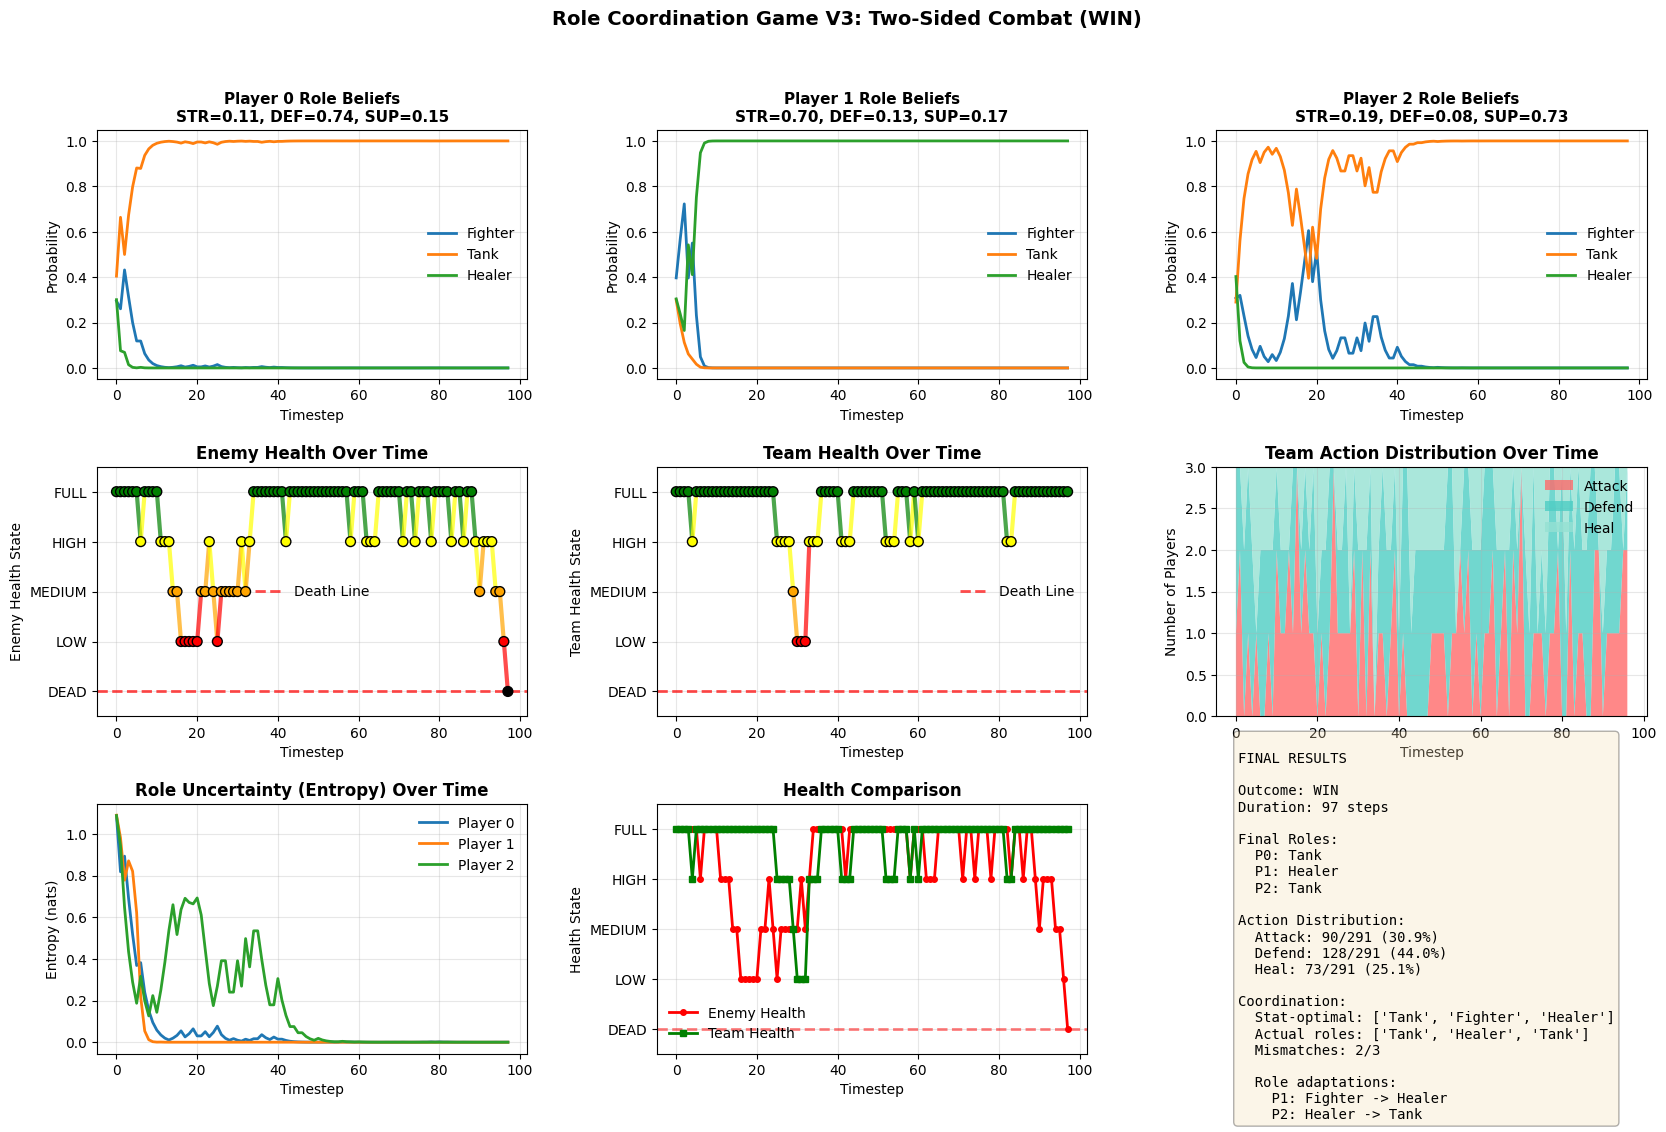

In [151]:
# Visualization
import matplotlib.pyplot as plt
import numpy as onp

# Create a figure with 6 subplots
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Row 1: Role probability evolution for each player
for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    
    # Calculate marginal probabilities for the current player at each timestep
    player_role_probs = [marginalize(role_prob_history[t], i) for t in range(n_steps)]
    # Add the initial timestep's probabilities
    player_role_probs.insert(0, marginalize(role_prior / role_prior.sum(), i))
    player_role_probs = onp.array(player_role_probs)

    # Plot the evolution of role probabilities
    for role in Role:
        ax.plot(range(n_steps + 1), player_role_probs[:, role], label=role.name, linewidth=2)

    # Add player stats to title
    stats = player_stats[i]
    title = f'Player {i} Role Beliefs\nSTR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}'
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Probability')
    ax.legend(frameon=False, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Row 2 Left: Enemy health over time
ax_enemy = fig.add_subplot(gs[1, 0])
health_names = ['DEAD', 'LOW', 'MEDIUM', 'HIGH', 'FULL']
health_colors = ['black', 'red', 'orange', 'yellow', 'green']
enemy_health_arr = onp.array(enemy_health_history)

# Plot with color coding
for i in range(len(enemy_health_arr) - 1):
    color = health_colors[int(enemy_health_arr[i])]
    ax_enemy.plot([i, i+1], [enemy_health_arr[i], enemy_health_arr[i+1]], 
                  color=color, linewidth=3, alpha=0.7)
    
ax_enemy.scatter(range(len(enemy_health_arr)), enemy_health_arr, 
                c=[health_colors[int(h)] for h in enemy_health_arr], 
                s=50, zorder=3, edgecolors='black', linewidth=1)
ax_enemy.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Death Line', alpha=0.7)
ax_enemy.set_title('Enemy Health Over Time', fontsize=12, fontweight='bold')
ax_enemy.set_xlabel('Timestep')
ax_enemy.set_ylabel('Enemy Health State')
ax_enemy.set_yticks(range(5))
ax_enemy.set_yticklabels(health_names)
ax_enemy.legend(frameon=False)
ax_enemy.grid(True, alpha=0.3)
ax_enemy.set_ylim([-0.5, 4.5])

# Row 2 Middle: Team health over time
ax_team = fig.add_subplot(gs[1, 1])
team_health_arr = onp.array(team_health_history)

# Plot with color coding
for i in range(len(team_health_arr) - 1):
    color = health_colors[int(team_health_arr[i])]
    ax_team.plot([i, i+1], [team_health_arr[i], team_health_arr[i+1]], 
                 color=color, linewidth=3, alpha=0.7)
    
ax_team.scatter(range(len(team_health_arr)), team_health_arr, 
               c=[health_colors[int(h)] for h in team_health_arr], 
               s=50, zorder=3, edgecolors='black', linewidth=1)
ax_team.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Death Line', alpha=0.7)
ax_team.set_title('Team Health Over Time', fontsize=12, fontweight='bold')
ax_team.set_xlabel('Timestep')
ax_team.set_ylabel('Team Health State')
ax_team.set_yticks(range(5))
ax_team.set_yticklabels(health_names)
ax_team.legend(frameon=False)
ax_team.grid(True, alpha=0.3)
ax_team.set_ylim([-0.5, 4.5])

# Row 2 Right: Action distribution over time
ax_actions = fig.add_subplot(gs[1, 2])
action_counts = onp.zeros((n_steps, 3))
for t in range(n_steps):
    for a in action_history[t]:
        action_counts[t, int(a)] += 1

ax_actions.stackplot(range(n_steps), 
                     action_counts[:, 0], action_counts[:, 1], action_counts[:, 2],
                     labels=['Attack', 'Defend', 'Heal'],
                     colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
                     alpha=0.8)
ax_actions.set_title('Team Action Distribution Over Time', fontsize=12, fontweight='bold')
ax_actions.set_xlabel('Timestep')
ax_actions.set_ylabel('Number of Players')
ax_actions.legend(loc='upper right', frameon=False)
ax_actions.grid(True, alpha=0.3)
ax_actions.set_ylim([0, 3])

# Row 3 Left: Role entropy over time
ax_entropy = fig.add_subplot(gs[2, 0])
from scipy.stats import entropy

role_entropy = onp.zeros((n_steps + 1, 3))
for i in range(3):
    # Initial entropy
    initial_marginal = marginalize(role_prior / role_prior.sum(), i)
    role_entropy[0, i] = entropy(onp.array(initial_marginal))
    
    # Entropy over time
    for t in range(n_steps):
        marginal = marginalize(role_prob_history[t], i)
        role_entropy[t + 1, i] = entropy(onp.array(marginal))

for i in range(3):
    ax_entropy.plot(range(n_steps + 1), role_entropy[:, i], label=f'Player {i}', linewidth=2)

ax_entropy.set_title('Role Uncertainty (Entropy) Over Time', fontsize=12, fontweight='bold')
ax_entropy.set_xlabel('Timestep')
ax_entropy.set_ylabel('Entropy (nats)')
ax_entropy.legend(frameon=False)
ax_entropy.grid(True, alpha=0.3)

# Row 3 Middle: Combined health comparison
ax_combined = fig.add_subplot(gs[2, 1])
ax_combined.plot(range(len(enemy_health_arr)), enemy_health_arr, 'r-', 
                label='Enemy Health', linewidth=2, marker='o', markersize=4)
ax_combined.plot(range(len(team_health_arr)), team_health_arr, 'g-', 
                label='Team Health', linewidth=2, marker='s', markersize=4)
ax_combined.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax_combined.set_title('Health Comparison', fontsize=12, fontweight='bold')
ax_combined.set_xlabel('Timestep')
ax_combined.set_ylabel('Health State')
ax_combined.set_yticks(range(5))
ax_combined.set_yticklabels(health_names)
ax_combined.legend(frameon=False)
ax_combined.grid(True, alpha=0.3)
ax_combined.set_ylim([-0.5, 4.5])

# Row 3 Right: Final statistics
ax_stats = fig.add_subplot(gs[2, 2])
ax_stats.axis('off')

# Calculate statistics
final_roles = [Role(onp.argmax(onp.array(marginalize(role_prob_history[-1], i)))).name for i in range(3)]
total_attacks = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Attack])
total_defends = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Defend])
total_heals = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Heal])
total_actions = total_attacks + total_defends + total_heals

best_roles = [Role(onp.argmax(player_stats[i])).name for i in range(3)]
mismatches = sum(1 for i in range(3) if best_roles[i] != final_roles[i])

stats_text = f"""
FINAL RESULTS

Outcome: {victory_status}
Duration: {n_steps} steps

Final Roles:
  P0: {final_roles[0]}
  P1: {final_roles[1]}
  P2: {final_roles[2]}

Action Distribution:
  Attack: {int(total_attacks)}/{int(total_actions)} ({100*total_attacks/total_actions:.1f}%)
  Defend: {int(total_defends)}/{int(total_actions)} ({100*total_defends/total_actions:.1f}%)
  Heal: {int(total_heals)}/{int(total_actions)} ({100*total_heals/total_actions:.1f}%)

Coordination:
  Stat-optimal: {best_roles}
  Actual roles: {final_roles}
  Mismatches: {mismatches}/3
"""

if mismatches > 0:
    stats_text += "\n  Role adaptations:"
    for i in range(3):
        if best_roles[i] != final_roles[i]:
            stats_text += f"\n    P{i}: {best_roles[i]} -> {final_roles[i]}"

ax_stats.text(0.05, 0.5, stats_text, fontsize=10, family='monospace', 
             verticalalignment='center', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle(f'Role Coordination Game V3: Two-Sided Combat ({victory_status})', 
            fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
